In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, roc_curve, auc
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from imblearn.over_sampling import SMOTE
!pip install shap
import shap


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<h2>Data Loading and Initial setup :</h2>

In [ ]:
# For better display as number of columns is large
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

#Loading the dataset
df = pd.read_csv("Data.csv")

#Basic interpretation of dataset
df.shape

(179338, 21)

In [ ]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,12,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",72.0,5.0,2.46,1.00,0.73,0.0,0.81,0.0,0.0,672.0,61.0,574.0,20.0,0.0,17.0
1,2023,12,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,7.0,4.25,0.00,1.00,0.0,1.75,0.0,0.0,348.0,252.0,0.0,33.0,0.0,63.0
2,2023,12,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",95.0,10.0,5.94,0.00,1.06,0.0,3.00,0.0,0.0,859.0,536.0,0.0,47.0,0.0,276.0
3,2023,12,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",23.0,2.0,0.56,0.00,0.00,0.0,1.44,1.0,0.0,75.0,9.0,0.0,0.0,0.0,66.0
4,2023,12,9E,Endeavor Air Inc.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",2111.0,256.0,76.88,8.75,52.43,0.0,117.94,1.0,0.0,21424.0,8906.0,732.0,1487.0,0.0,10299.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179338 entries, 0 to 179337
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 179338 non-null  int64  
 1   month                179338 non-null  int64  
 2   carrier              179338 non-null  object 
 3   carrier_name         179338 non-null  object 
 4   airport              179338 non-null  object 
 5   airport_name         179338 non-null  object 
 6   arr_flights          178997 non-null  float64
 7   arr_del15            178747 non-null  float64
 8   carrier_ct           178997 non-null  float64
 9   weather_ct           178997 non-null  float64
 10  nas_ct               178997 non-null  float64
 11  security_ct          178997 non-null  float64
 12  late_aircraft_ct     178997 non-null  float64
 13  arr_cancelled        178997 non-null  float64
 14  arr_diverted         178997 non-null  float64
 15  arr_delay        

In [ ]:
categorical_columns = ['carrier', 'carrier_name', 'airport', 'airport_name', 'year', 'month']

for col in categorical_columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")

carrier: 29 unique values
carrier_name: 39 unique values
airport: 396 unique values
airport_name: 420 unique values
year: 9 unique values
month: 12 unique values


<h2>Basic Data Cleaning & Inspection :</h2>



In [ ]:
missing_values = df.isnull().sum()

missing_values.sort_values(ascending=False)

arr_del15              591
weather_ct             341
carrier_ct             341
arr_flights            341
security_ct            341
weather_delay          341
arr_diverted           341
arr_delay              341
carrier_delay          341
security_delay         341
nas_ct                 341
late_aircraft_ct       341
arr_cancelled          341
late_aircraft_delay    341
nas_delay              341
airport                  0
month                    0
year                     0
carrier_name             0
carrier                  0
airport_name             0
dtype: int64

In [ ]:
print("Total rows with any missing values:", df[df.isnull().any(axis=1)].shape[0])

Total rows with any missing values: 591


In [ ]:
# Confirm if rows with missing arr_del15 are exactly the same as those with any missing value because both are equal in number
missing_arr_del15_rows = df[df['arr_del15'].isnull()]
missing_any_rows = df[df.isnull().any(axis=1)]

print("Are both sets equal?", missing_arr_del15_rows.equals(missing_any_rows))

Are both sets equal? True


Dropping rows where 'arr_del15' is missing

In [ ]:
df_clean = df.dropna(subset=['arr_del15'])

# Resetting index to avoid confusion
df_clean.reset_index(drop=True, inplace=True)

In [ ]:
print("Shape after removing rows with missing critical delay data:", df_clean.shape)
print("\nRemaining missing values (should be 0):")
print(df_clean.isnull().sum())

Shape after removing rows with missing critical delay data: (178747, 21)

Remaining missing values (should be 0):
year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64


In [ ]:
# Checking for duplicates
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

Total duplicate rows: 0


<h2> Creating Target Variables :</h2>

In [ ]:
# Classification Target: Was there any delay over 15 minutes?
df_clean['is_delayed'] = df_clean['arr_del15'].apply(lambda x: 1 if x > 0 else 0)

# Regression Target: I am directly using 'arr_delay' as it already represents total delay in minutes

# New targets
df_clean[['arr_del15', 'is_delayed', 'arr_delay']].head()

,arr_del15,is_delayed,arr_delay
0,5.0,1,672.0
1,7.0,1,348.0
2,10.0,1,859.0
3,2.0,1,75.0
4,256.0,1,21424.0


<h2>Exploratory Data Analysis (EDA)</h2>

<h4> Basic Distribution Analysis</h4>

In [ ]:
df_clean["is_delayed"].value_counts()

is_delayed
1    170374
0      8373
Name: count, dtype: int64

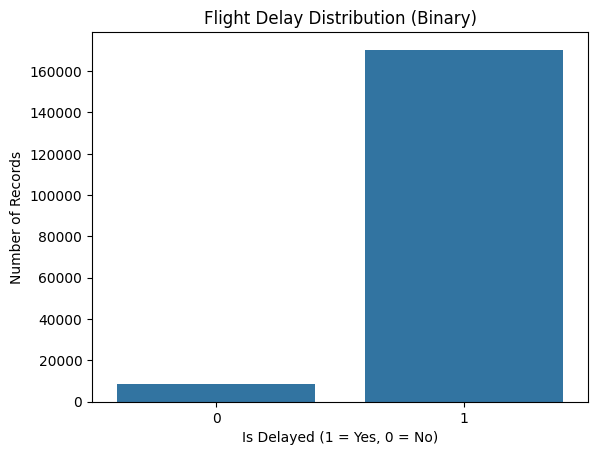

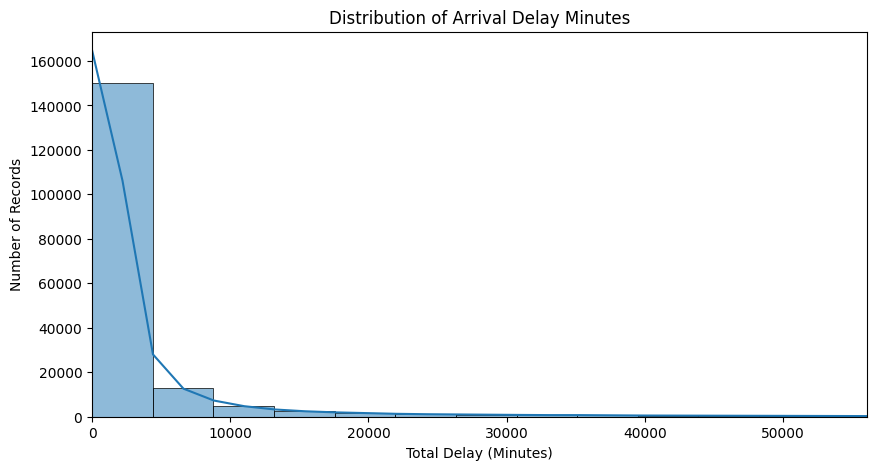

In [ ]:
# Plotting delay vs no delay (classification target)
sns.countplot(data=df_clean, x='is_delayed')
plt.title('Flight Delay Distribution (Binary)')
plt.xlabel('Is Delayed (1 = Yes, 0 = No)')
plt.ylabel('Number of Records')
plt.show()

# Plotting distribution of delay minutes (regression target)
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['arr_delay'], bins=100, kde=True)
plt.title('Distribution of Arrival Delay Minutes')
plt.xlabel('Total Delay (Minutes)')
plt.ylabel('Number of Records')
plt.xlim(0, df_clean['arr_delay'].quantile(0.99))  # limit to 99th percentile for clarity
plt.show()

It shows most of the flights were delayed ( making it a highly imbalanced dataset ). <br>
Total Delay minutes mostly lie under 15000 minutes.

<h4>Time-Based Patterns (Month, Year, Seasonality)</h4>

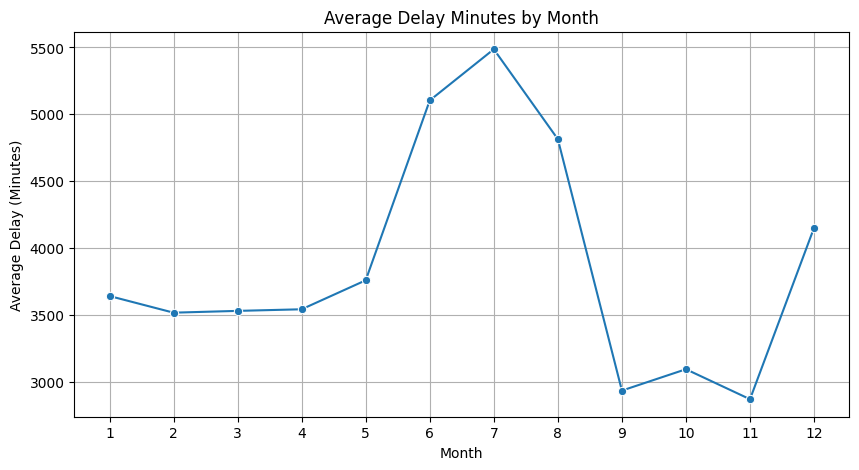

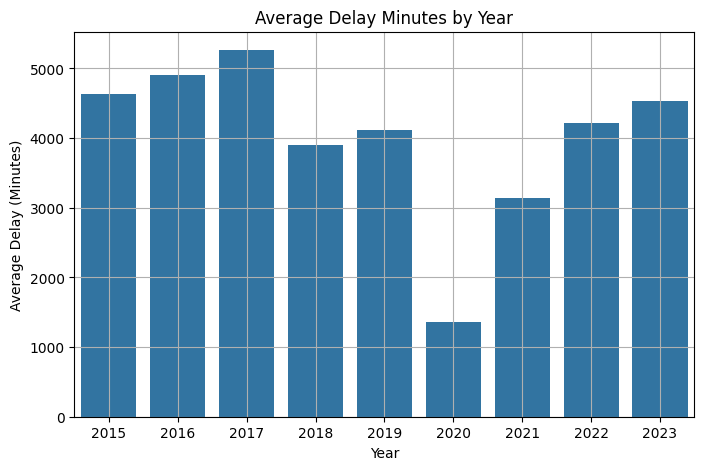

In [ ]:
# Average delay by month
plt.figure(figsize=(10, 5))
monthly_avg = df_clean.groupby('month')['arr_delay'].mean()
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title('Average Delay Minutes by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay (Minutes)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

# Average delay by year
plt.figure(figsize=(8, 5))
yearly_avg = df_clean.groupby('year')['arr_delay'].mean()
sns.barplot(x=yearly_avg.index, y=yearly_avg.values)
plt.title('Average Delay Minutes by Year')
plt.xlabel('Year')
plt.ylabel('Average Delay (Minutes)')
plt.grid(True)
plt.show()

Delays were dipped during the pandemic and have been climbing back post-COVID, likely due to increased demand but operational strain.<br>
Delays show seasonal patterns, with summer vacation and year-end holidays being the worst.

<h4> Carrier & Airport Delay Analysis</h4>

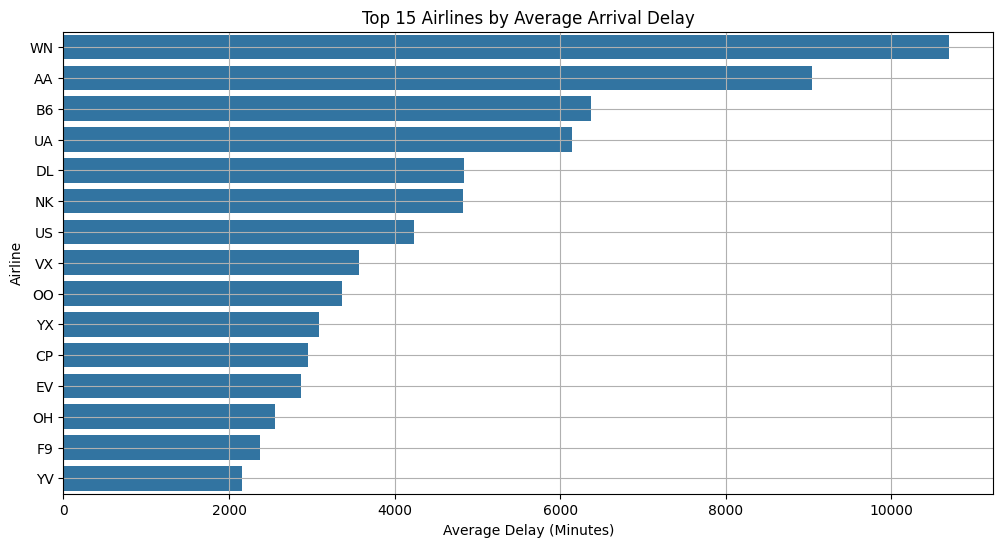

In [ ]:
# Average delay by carrier

# Top 15 carriers by average delay
plt.figure(figsize=(12, 6))
carrier_avg = df_clean.groupby('carrier')['arr_delay'].mean().sort_values(ascending=False).head(15)
sns.barplot(y=carrier_avg.index, x=carrier_avg.values)
plt.title('Top 15 Airlines by Average Arrival Delay')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Airline')
plt.grid(True)
plt.show()

WN (Southwest) and AA (American Airlines) have the highest delays.<br>
Big legacy carriers like UA (United), DL (Delta), and B6 (JetBlue) follow.

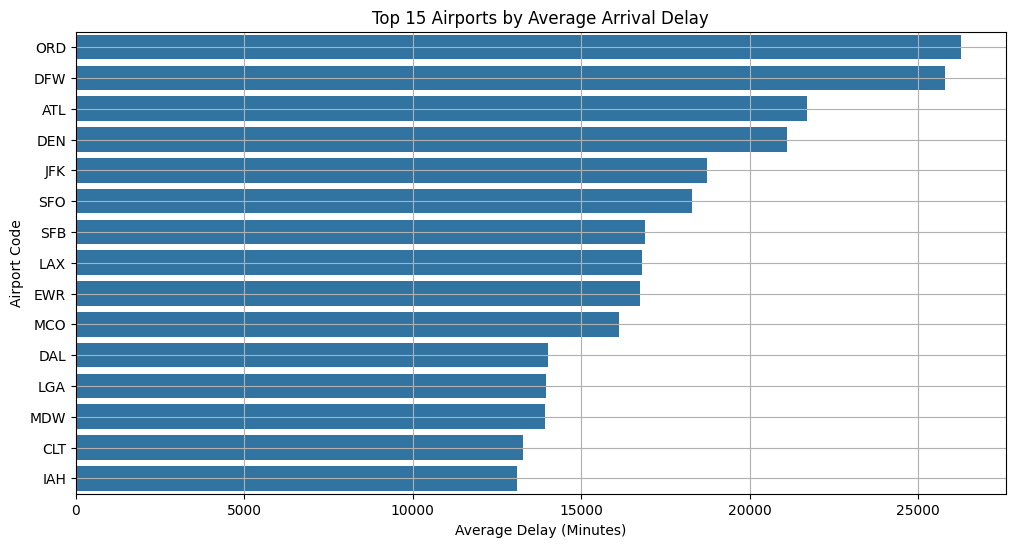

In [ ]:
# Average delay by airport code
plt.figure(figsize=(12, 6))
airport_avg = df_clean.groupby('airport')['arr_delay'].mean().sort_values(ascending=False).head(15)
sns.barplot(y=airport_avg.index, x=airport_avg.values)
plt.title('Top 15 Airports by Average Arrival Delay')
plt.xlabel('Average Delay (Minutes)')
plt.ylabel('Airport Code')
plt.grid(True)
plt.show()

Major hubs like ORD (Chicago O'Hare), DFW (Dallas/Fort Worth), ATL (Atlanta), DEN (Denver), and JFK (New York) top the list.

<h4> Delay Cause Breakdown</h4>

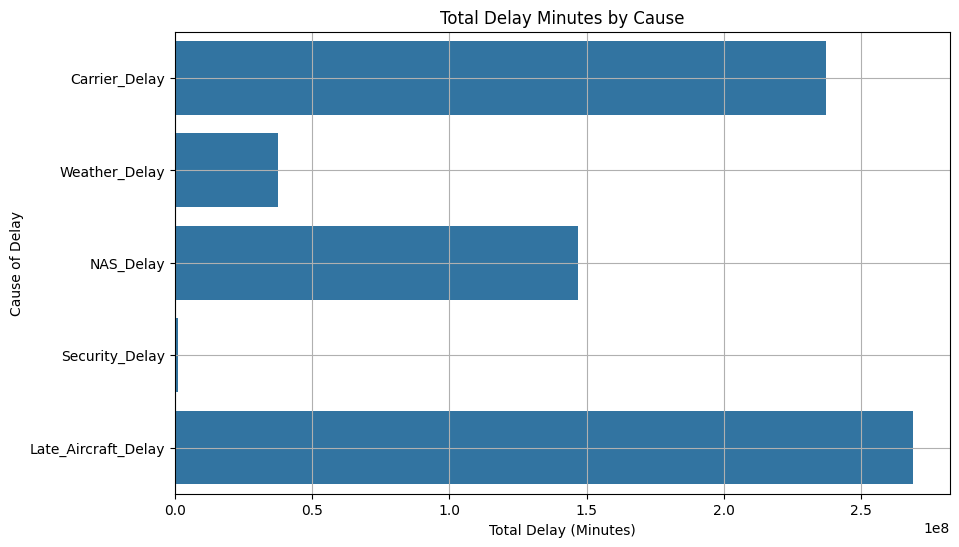

In [ ]:
# Total delay minutes by cause

delay_cause_totals = {
    'Carrier_Delay': df_clean['carrier_delay'].sum(),
    'Weather_Delay': df_clean['weather_delay'].sum(),
    'NAS_Delay': df_clean['nas_delay'].sum(),
    'Security_Delay': df_clean['security_delay'].sum(),
    'Late_Aircraft_Delay': df_clean['late_aircraft_delay'].sum()
}

# Plotting on bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=list(delay_cause_totals.values()), y=list(delay_cause_totals.keys()))
plt.title('Total Delay Minutes by Cause')
plt.xlabel('Total Delay (Minutes)')
plt.ylabel('Cause of Delay')
plt.grid(True)
plt.show()

In [ ]:
print((delay_cause_totals["Carrier_Delay"] + delay_cause_totals["Late_Aircraft_Delay"])/(delay_cause_totals["Carrier_Delay"] +delay_cause_totals["Late_Aircraft_Delay"] + delay_cause_totals["Security_Delay"]+delay_cause_totals["NAS_Delay"]+delay_cause_totals["Weather_Delay"]))

0.7318609341812071


In [ ]:
delay_cause_totals

{'Carrier_Delay': np.float64(237268793.0),
 'Weather_Delay': np.float64(37430676.0),
 'NAS_Delay': np.float64(146768462.0),
 'Security_Delay': np.float64(1224329.0),
 'Late_Aircraft_Delay': np.float64(268827517.0)}

INSIGHTS (Root Cause Analysis):<BR>
Late Aircraft Delay is the top contributor to total delay minutes.<BR>
Carrier Delay is a second in list.<BR>
NAS Delay is also significant.<BR>
Weather Delay is much lower than expected — possibly due to cancellations instead of delays.<BR>
Security Delay is negligible.<br>
<b>IMPORTANT</b> : Most delays are caused by controllable factors like Late Aircraft and Carrier issues.<br>
This insight will guide our predictive modeling, OAI metric (to prioritize controllable delays), and SHAP-based explainability.

<h2>Some extra plots :</h2>

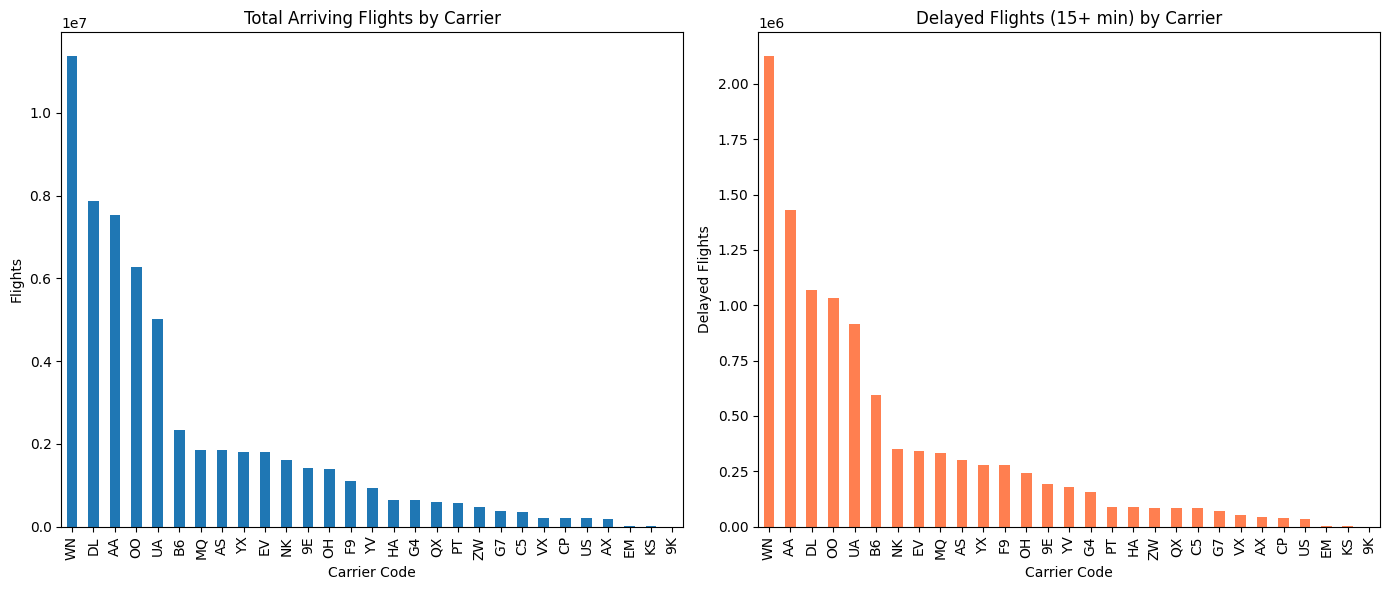

In [ ]:
# Total arriving flights by carrier
carrier_flights = df.groupby("carrier")["arr_flights"].sum().sort_values(ascending=False)

# Total delayed flights (15+ min) by carrier
carrier_delays = df.groupby("carrier")["arr_del15"].sum().sort_values(ascending=False)

# Plotting side by side
plt.figure(figsize=(14, 6))

# Flights
plt.subplot(1, 2, 1)
carrier_flights.plot(kind='bar')
plt.title("Total Arriving Flights by Carrier")
plt.ylabel("Flights")
plt.xlabel("Carrier Code")

# Delays
plt.subplot(1, 2, 2)
carrier_delays.plot(kind='bar', color='coral')
plt.title("Delayed Flights (15+ min) by Carrier")
plt.ylabel("Delayed Flights")
plt.xlabel("Carrier Code")

plt.tight_layout()
plt.show()

Though we have already found out , This helps identify which carriers have the most flights and the most delays.

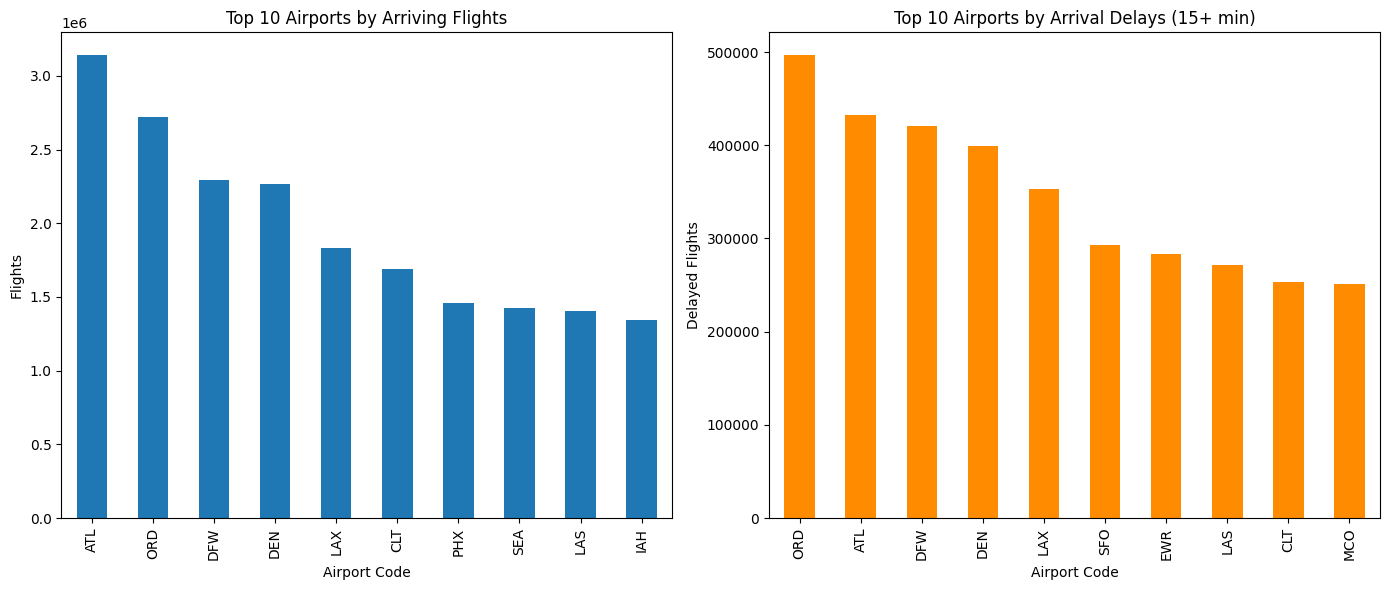

In [ ]:
# Top 10 Busiest Airports by Flights & Delays
# Total flights by airport
airport_flights = df.groupby("airport")["arr_flights"].sum().sort_values(ascending=False).head(10)

# Total delays (15+ min) by airport
airport_delays = df.groupby("airport")["arr_del15"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(14, 6))

# Flights
plt.subplot(1, 2, 1)
airport_flights.plot(kind='bar')
plt.title("Top 10 Airports by Arriving Flights")
plt.ylabel("Flights")
plt.xlabel("Airport Code")

# Delays
plt.subplot(1, 2, 2)
airport_delays.plot(kind='bar', color='darkorange')
plt.title("Top 10 Airports by Arrival Delays (15+ min)")
plt.ylabel("Delayed Flights")
plt.xlabel("Airport Code")

plt.tight_layout()
plt.show()

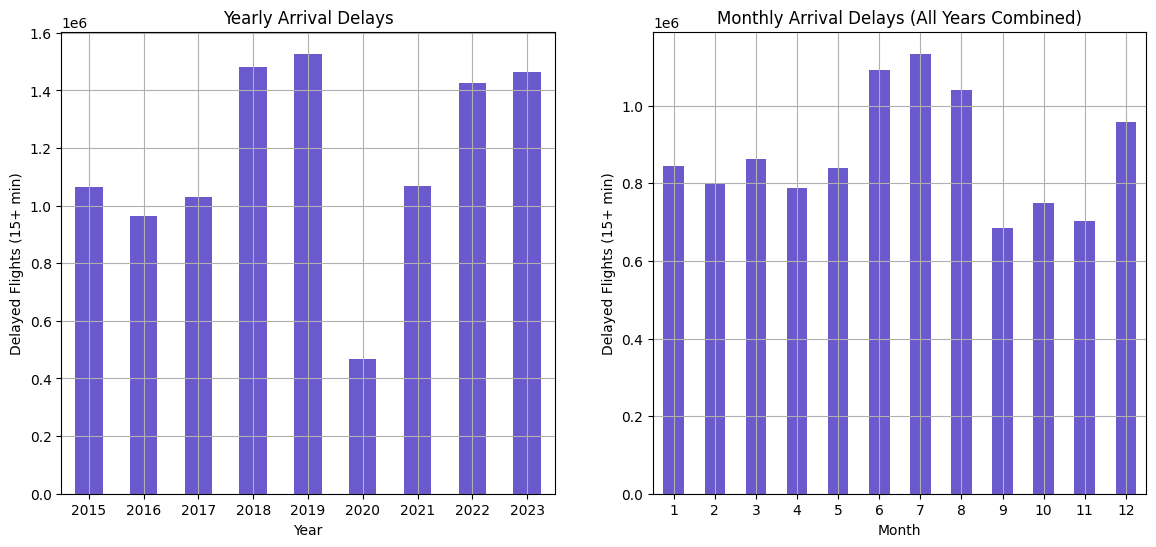

In [ ]:
# Step 4.1: Group by year, sum delays
yearly_delays = df.groupby("year")["arr_del15"].sum()

# Step 4.1: Group by month, sum delays
monthly_delays = df.groupby("month")["arr_del15"].sum()

# Step 4.2: Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
yearly_delays.plot(kind='bar', color='slateblue')
plt.title("Yearly Arrival Delays")
plt.xlabel("Year")
plt.ylabel("Delayed Flights (15+ min)")
plt.xticks(rotation=0)
plt.grid(True)

plt.subplot(1, 2, 2)
monthly_delays.plot(kind='bar', color='slateblue')
plt.title("Monthly Arrival Delays (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Delayed Flights (15+ min)")
plt.xticks(rotation=0)
plt.grid(True)



plt.show()

INSIGHT : delays are seasonal . Ex- peak in summer or holidays. plus covid year

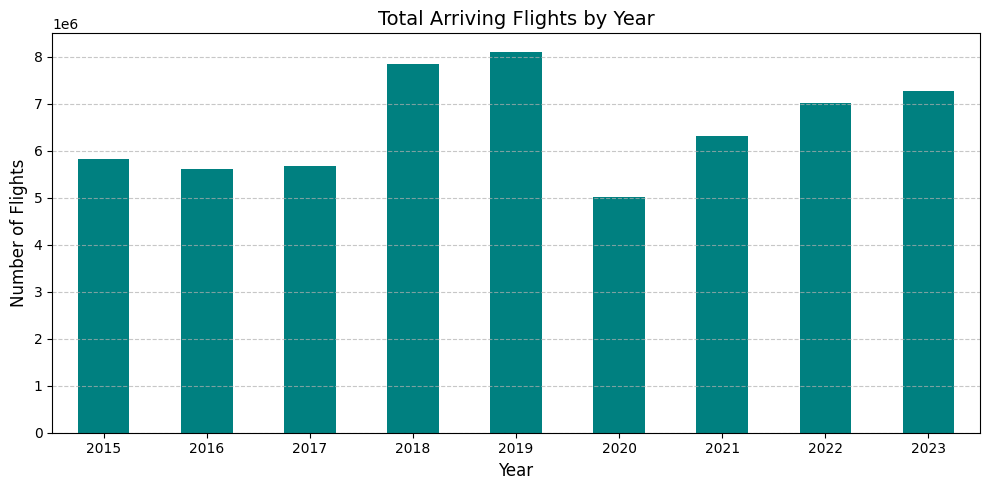

In [ ]:
#  Groupingg data by year and sum the arriving flights
flights_per_year = df.groupby("year")["arr_flights"].sum()

plt.figure(figsize=(10, 5))
flights_per_year.plot(kind='bar', color='teal')

# Adding titles and labels
plt.title("Total Arriving Flights by Year", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

INSIGHTS : The overall flight traffic trend over time.
You may notice dips during pandemic years (like 2020–2021).

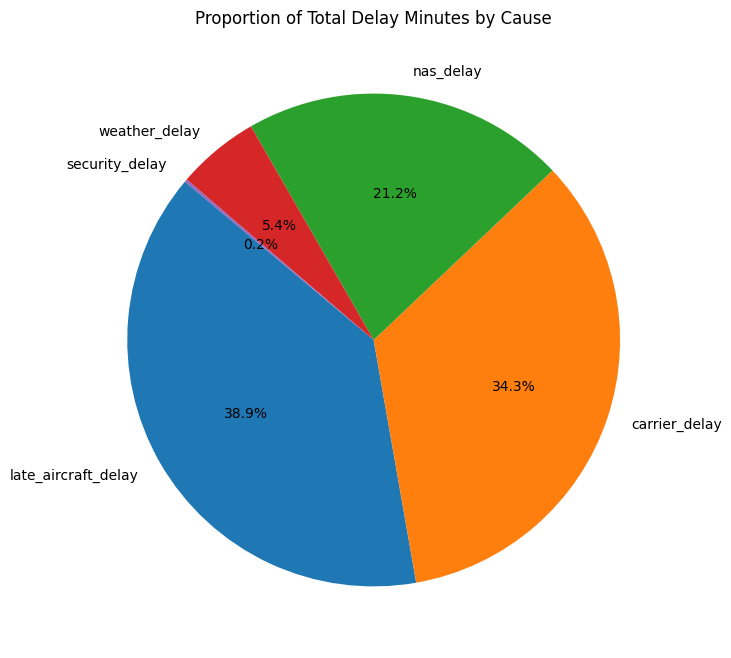

In [ ]:
# Delay causes
delay_causes = df[[
    "carrier_delay", "weather_delay", "nas_delay",
    "security_delay", "late_aircraft_delay"
]].sum().sort_values(ascending=False)

# Plotting as pie chart
plt.figure(figsize=(8, 8))
delay_causes.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Total Delay Minutes by Cause")
plt.ylabel("")
plt.show()

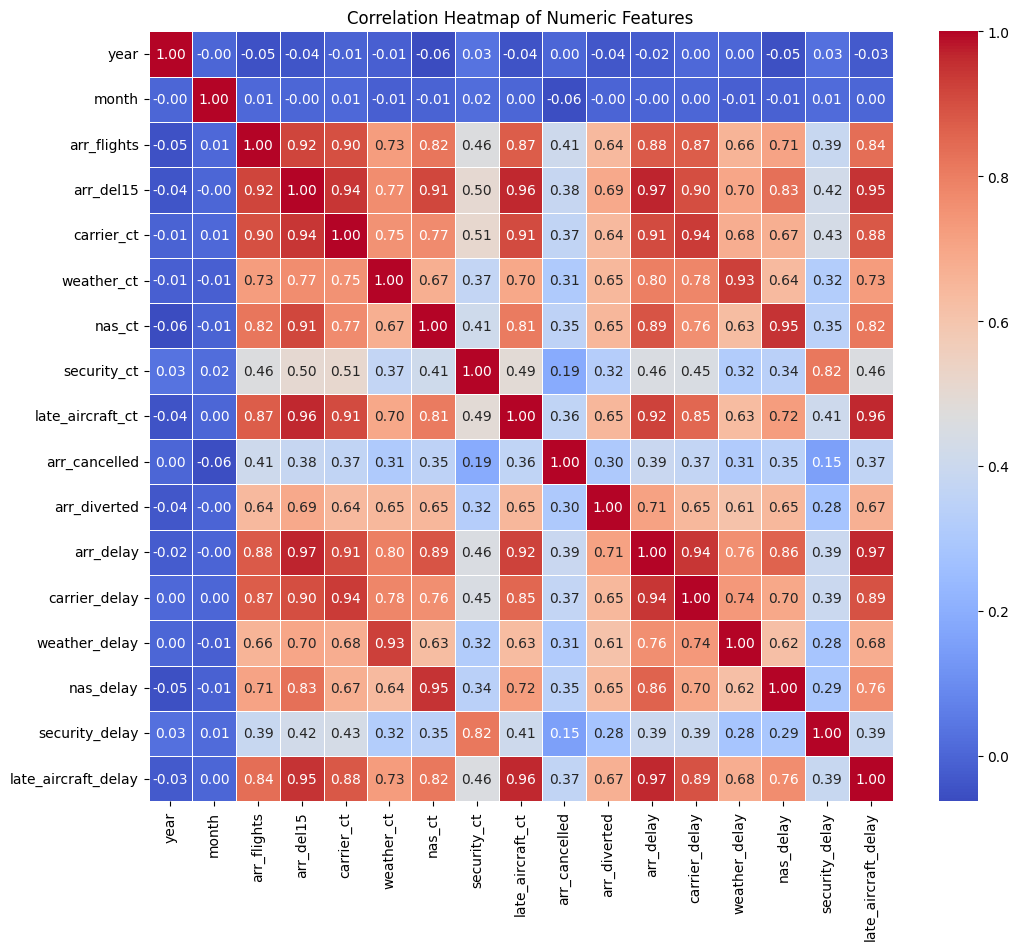

In [ ]:
# Selecting numerical columns
numerics = df.select_dtypes(include=['float64', 'int64'])

# Computing correlation
corr = numerics.corr()

# Plotting heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

<h2>Feature Engineering & Data Preparation:</h2>

<h4> Selecting Relevant Columns</h4>

In [ ]:
# Select relevant features

# Dropping descriptive/redundant columns
df_model = df_clean.drop(columns=[
    'airport_name', 'carrier_name',  # Descriptive only
    'arr_del15',                     # Target proxy for classification
])

# Preview columns
df_model.columns

Index(['year', 'month', 'carrier', 'airport', 'arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct',
       'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay', 'is_delayed'],
      dtype='object')

<h4> Encoding Categorical Features (carrier, airport, month, etc.)</h4>

In [ ]:
# I am using One-Hot Encoding as it is safe and works well with tree-based models (like Random Forest, XGBoost).

In [ ]:
# One-hot encode categorical variables

# Categorical features
categorical_cols = ['carrier', 'airport', 'month', 'year']

# One-hot encode
df_model_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Printing new shape and sample
print("Encoded dataset shape:", df_model_encoded.shape)
df_model_encoded.head()

Encoded dataset shape: (178747, 454)


,arr_flights,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,is_delayed,carrier_9K,carrier_AA,carrier_AS,carrier_AX,carrier_B6,carrier_C5,carrier_CP,carrier_DL,carrier_EM,carrier_EV,carrier_F9,carrier_G4,carrier_G7,carrier_HA,carrier_KS,carrier_MQ,carrier_NK,carrier_OH,carrier_OO,carrier_PT,carrier_QX,carrier_UA,carrier_US,carrier_VX,carrier_WN,carrier_YV,carrier_YX,carrier_ZW,airport_ABI,airport_ABQ,airport_ABR,airport_ABY,airport_ACK,airport_ACT,airport_ACV,airport_ACY,airport_ADK,airport_ADQ,airport_AEX,airport_AGS,airport_AKN,airport_ALB,airport_ALO,airport_ALS,airport_ALW,airport_AMA,airport_ANC,airport_APN,airport_ART,airport_ASE,airport_ATL,airport_ATW,airport_ATY,airport_AUS,airport_AVL,airport_AVP,airport_AZA,airport_AZO,airport_BDL,airport_BET,airport_BFF,airport_BFL,airport_BFM,airport_BGM,airport_BGR,airport_BHM,airport_BIH,airport_BIL,airport_BIS,airport_BJI,airport_BKG,airport_BLI,airport_BLV,airport_BMI,airport_BNA,airport_BOI,airport_BOS,airport_BPT,airport_BQK,airport_BQN,airport_BRD,airport_BRO,airport_BRW,airport_BTM,airport_BTR,airport_BTV,airport_BUF,airport_BUR,airport_BWI,airport_BZN,airport_CAE,airport_CAK,airport_CDB,airport_CDC,airport_CDV,airport_CEC,airport_CGI,airport_CHA,airport_CHO,airport_CHS,airport_CID,airport_CIU,airport_CKB,airport_CLD,airport_CLE,airport_CLL,airport_CLT,airport_CMH,airport_CMI,airport_CMX,airport_CNY,airport_COD,airport_COS,airport_COU,airport_CPR,airport_CRP,airport_CRW,airport_CSG,airport_CVG,airport_CWA,airport_CYS,airport_DAB,airport_DAL,airport_DAY,airport_DBQ,airport_DCA,airport_DDC,airport_DEC,airport_DEN,airport_DFW,airport_DHN,airport_DIK,airport_DLG,airport_DLH,airport_DRO,airport_DRT,airport_DSM,airport_DTW,airport_DUT,airport_DVL,airport_EAR,airport_EAT,airport_EAU,airport_ECP,airport_EGE,airport_EKO,airport_ELM,airport_ELP,airport_ERI,airport_ESC,airport_EUG,airport_EVV,airport_EWN,airport_EWR,airport_EYW,airport_FAI,airport_FAR,airport_FAT,airport_FAY,airport_FCA,airport_FLG,airport_FLL,airport_FLO,airport_FNL,airport_FNT,airport_FOD,airport_FSD,airport_FSM,airport_FWA,airport_GCC,airport_GCK,airport_GEG,airport_GFK,airport_GGG,airport_GJT,airport_GNV,airport_GPT,airport_GRB,airport_GRI,airport_GRK,airport_GRR,airport_GSO,airport_GSP,airport_GST,airport_GTF,airport_GTR,airport_GUC,airport_GUM,airport_HDN,airport_HGR,airport_HHH,airport_HIB,airport_HLN,airport_HNL,airport_HOB,airport_HOU,airport_HPN,airport_HRL,airport_HSV,airport_HTS,airport_HVN,airport_HYA,airport_HYS,airport_IAD,airport_IAG,airport_IAH,airport_ICT,airport_IDA,airport_IFP,airport_ILG,airport_ILM,airport_IMT,airport_IND,airport_INL,airport_IPT,airport_ISN,airport_ISP,airport_ITH,airport_ITO,airport_JAC,airport_JAN,airport_JAX,airport_JFK,airport_JHM,airport_JLN,airport_JMS,airport_JNU,airport_JST,airport_KOA,airport_KTN,airport_LAN,airport_LAR,airport_LAS,airport_LAW,airport_LAX,airport_LBB,airport_LBE,airport_LBF,airport_LBL,airport_LCH,airport_LCK,airport_LEX,airport_LFT,airport_LGA,airport_LGB,airport_LIH,airport_LIT,airport_LNK,airport_LNY,airport_LRD,airport_LSE,airport_LWB,airport_LWS,airport_LYH,airport_MAF,airport_MBS,airport_MCI,airport_MCO,airport_MCW,airport_MDT,airport_MDW,airport_MEI,airport_MEM,airport_MFE,airport_MFR,airport_MGM,airport_MHK,airport_MHT,airport_MIA,airport_MKE,airport_MKG,airport_MKK,airport_MLB,airport_MLI,airport_MLU,airport_MMH,airport_MOB,airport_MOT,airport_MQT,airport_MRY,airport_MSN,airport_MSO,airport_MSP,airport_MSY,airport_MTJ,airport_MVY,airport_MYR,airport_OAJ,airport_OAK,airport_OGD,airport_OGG,airport_OGS,airport_OKC,airport_OMA,airport_OME,airport_ONT,airport_ORD,airport_ORF,airport_ORH,airport_OTH,airport_OTZ,airport_OWB,airport_PAE,airport_PAH,airport_PBG,airport_PBI,airport_PDX,airport_PGD,airport_PGV,airport_PHF,airport_PHL,airport_PHX,airport_PIA,airport_PIB,airport_PIE,airport_PIH,airport_PIR,airport_PIT,airport_PLN,airport_

In [ ]:
df_model_encoded.columns

Index(['arr_flights', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled',
       'arr_diverted', 'arr_delay', 'carrier_delay',
       ...
       'month_11', 'month_12', 'year_2016', 'year_2017', 'year_2018', 'year_2019', 'year_2020', 'year_2021',
       'year_2022', 'year_2023'],
      dtype='object', length=454)

<h4> Classification & Regression Datasets</h4>

In [ ]:
# Preparing final datasets with non-leaky features

# Defining columns which can cause delay.
leaky_keywords = ['delay', 'ct', 'cancel', 'divert', 'arr_flights']

# Selecting only clean features
clean_features = [
    col for col in df_model_encoded.columns
    if col not in ['is_delayed', 'arr_delay'] and not any(key in col.lower() for key in leaky_keywords)
]

# 1. Classification data
X_class = df_model_encoded[clean_features]
y_class = df_model_encoded['is_delayed']

# 2. Regression data
X_reg = df_model_encoded[clean_features]
y_reg = df_model_encoded['arr_delay']

# Printing shapes
print("Classification - Features shape:", X_class.shape, "| Target shape:", y_class.shape)
print("Regression - Features shape:", X_reg.shape, "| Target shape:", y_reg.shape)


Classification - Features shape: (178747, 436) | Target shape: (178747,)
Regression - Features shape: (178747, 436) | Target shape: (178747,)


In [ ]:
clean_features

['carrier_9K',
 'carrier_AA',
 'carrier_AS',
 'carrier_AX',
 'carrier_B6',
 'carrier_C5',
 'carrier_CP',
 'carrier_DL',
 'carrier_EM',
 'carrier_EV',
 'carrier_F9',
 'carrier_G4',
 'carrier_G7',
 'carrier_HA',
 'carrier_KS',
 'carrier_MQ',
 'carrier_NK',
 'carrier_OH',
 'carrier_OO',
 'carrier_PT',
 'carrier_QX',
 'carrier_UA',
 'carrier_US',
 'carrier_VX',
 'carrier_WN',
 'carrier_YV',
 'carrier_YX',
 'carrier_ZW',
 'airport_ABI',
 'airport_ABQ',
 'airport_ABR',
 'airport_ABY',
 'airport_ACK',
 'airport_ACV',
 'airport_ACY',
 'airport_ADK',
 'airport_ADQ',
 'airport_AEX',
 'airport_AGS',
 'airport_AKN',
 'airport_ALB',
 'airport_ALO',
 'airport_ALS',
 'airport_ALW',
 'airport_AMA',
 'airport_ANC',
 'airport_APN',
 'airport_ART',
 'airport_ASE',
 'airport_ATL',
 'airport_ATW',
 'airport_ATY',
 'airport_AUS',
 'airport_AVL',
 'airport_AVP',
 'airport_AZA',
 'airport_AZO',
 'airport_BDL',
 'airport_BET',
 'airport_BFF',
 'airport_BFL',
 'airport_BFM',
 'airport_BGM',
 'airport_BGR',
 'ai

<h2> Model Building</h2>

<h4> Train-Test Split and SMOTE Resampling</h4>

In [ ]:
# Train-test splits

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=7, stratify=y_class
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=7
)

# Printing shapes
print("Classification - Train:", X_train_class.shape, "| Test:", X_test_class.shape)
print("Regression - Train:", X_train_reg.shape, "| Test:", X_test_reg.shape)


Classification - Train: (142997, 436) | Test: (35750, 436)
Regression - Train: (142997, 436) | Test: (35750, 436)


In [ ]:
# Converting target to integer type
y_train_class = y_train_class.astype(int)

# Ensuring X is a proper DataFrame with only numeric columns
X_train_class = X_train_class.copy()
X_train_class = X_train_class.astype(float)

# Applying SMOTE
sm = SMOTE(random_state=7 , sampling_strategy = 0.3)
X_train_class_res, y_train_class_res = sm.fit_resample(X_train_class, y_train_class)

# Checking new class balance
print("Class distribution before SMOTE:", np.bincount(y_train_class))
print("Class distribution after SMOTE:", np.bincount(y_train_class_res))


Class distribution before SMOTE: [  6698 136299]
Class distribution after SMOTE: [ 40889 136299]


<h4>Utility Function to Evaluate Classifiers</h4>

In [ ]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Training model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Printing evaluation metrics
    print(f"\n Evaluation for {model_name} (Threshold = 0.50)")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # ROC-AUC
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {auc:.4f}")

    # Plotting ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return model, y_proba


 Evaluation for Random Forest (Threshold = 0.50)
              precision    recall  f1-score   support

           0       0.26      0.10      0.14      1675
           1       0.96      0.99      0.97     34075

    accuracy                           0.94     35750
   macro avg       0.61      0.54      0.56     35750
weighted avg       0.92      0.94      0.93     35750

Confusion Matrix:
 [[  163  1512]
 [  456 33619]]
ROC-AUC Score: 0.7771


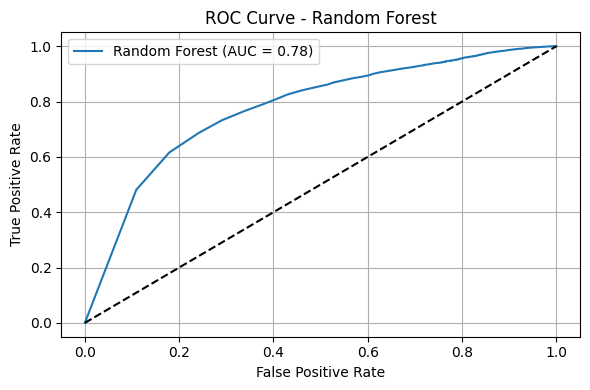

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=7)
rf_model, rf_proba = evaluate_classifier(
    rf_model, X_train_class_res, y_train_class_res, X_test_class, y_test_class, "Random Forest"
)


 Evaluation for Logistic Regression (Threshold = 0.50)
              precision    recall  f1-score   support

           0       0.18      0.25      0.21      1675
           1       0.96      0.94      0.95     34075

    accuracy                           0.91     35750
   macro avg       0.57      0.60      0.58     35750
weighted avg       0.93      0.91      0.92     35750

Confusion Matrix:
 [[  426  1249]
 [ 1997 32078]]
ROC-AUC Score: 0.7639


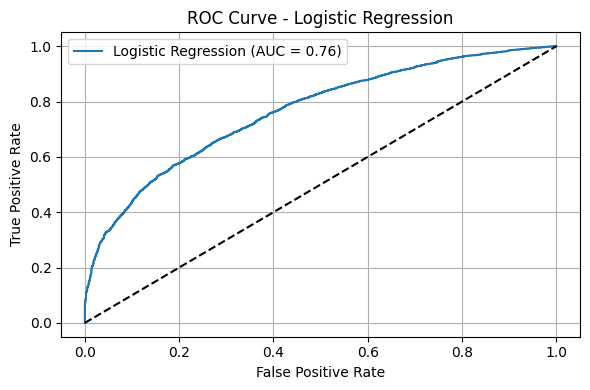

In [ ]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model, lr_proba = evaluate_classifier(
    lr_model, X_train_class_res, y_train_class_res, X_test_class, y_test_class, "Logistic Regression"
)


 Evaluation for XGBoost (Threshold = 0.50)
              precision    recall  f1-score   support

           0       0.41      0.10      0.16      1675
           1       0.96      0.99      0.97     34075

    accuracy                           0.95     35750
   macro avg       0.68      0.55      0.57     35750
weighted avg       0.93      0.95      0.94     35750

Confusion Matrix:
 [[  173  1502]
 [  250 33825]]
ROC-AUC Score: 0.7854


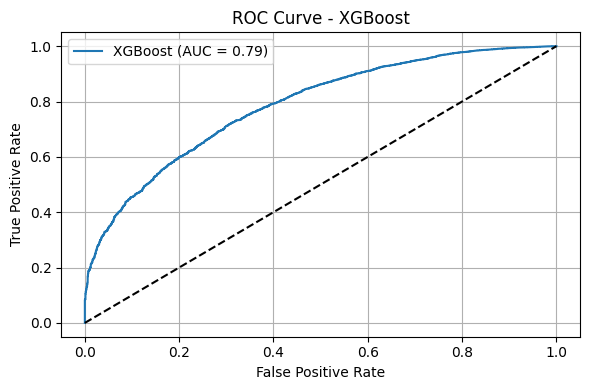

In [ ]:
# XGB model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=7)
xgb_model, xgb_proba = evaluate_classifier(
 xgb_model, X_train_class_res, y_train_class_res, X_test_class, y_test_class, "XGBoost"
    )

<h2> Utility Function to Find Best Threshold</h2>

In [ ]:
def tune_threshold_youden(y_true, y_proba, model_name="Model"):
    thresholds = np.arange(0.01, 0.91, 0.01)
    best_j = -1
    best_threshold = 0.5

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn)  # recall
        specificity = tn / (tn + fp)
        j = sensitivity + specificity - 1
        if j > best_j:
            best_j = j
            best_threshold = t

    print(f"\n Best Threshold (Youden's J) for {model_name}: {best_threshold:.2f} (J = {best_j:.4f})")
    return best_threshold

In [ ]:
rf_thresh = tune_threshold_youden(y_test_class, rf_proba, "Random Forest")
lr_thresh = tune_threshold_youden(y_test_class, lr_proba, "Logistic Regression")
xgb_thresh = tune_threshold_youden(y_test_class, xgb_proba, "XGBoost")


 Best Threshold (Youden's J) for Random Forest: 0.90 (J = 0.3469)

 Best Threshold (Youden's J) for Logistic Regression: 0.83 (J = 0.3804)

 Best Threshold (Youden's J) for XGBoost: 0.87 (J = 0.4105)


In [ ]:
def evaluate_at_custom_threshold(y_true, y_proba, threshold, model_name="Model"):
    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n Evaluation for {model_name} at Threshold = {threshold:.2f}")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


In [ ]:
evaluate_at_custom_threshold(y_test_class, rf_proba, rf_thresh, "Random Forest")
evaluate_at_custom_threshold(y_test_class, lr_proba, lr_thresh, "Logistic Regression")
evaluate_at_custom_threshold(y_test_class, xgb_proba, xgb_thresh, "XGBoost")



 Evaluation for Random Forest at Threshold = 0.90
              precision    recall  f1-score   support

           0       0.15      0.49      0.23      1675
           1       0.97      0.86      0.91     34075

    accuracy                           0.84     35750
   macro avg       0.56      0.67      0.57     35750
weighted avg       0.93      0.84      0.88     35750

Confusion Matrix:
 [[  814   861]
 [ 4739 29336]]

 Evaluation for Logistic Regression at Threshold = 0.83
              precision    recall  f1-score   support

           0       0.08      0.81      0.15      1675
           1       0.98      0.57      0.72     34075

    accuracy                           0.58     35750
   macro avg       0.53      0.69      0.44     35750
weighted avg       0.94      0.58      0.70     35750

Confusion Matrix:
 [[ 1357   318]
 [14643 19432]]

 Evaluation for XGBoost at Threshold = 0.87
              precision    recall  f1-score   support

           0       0.11      0.70     

Random Forest is the best balance between accuracy, recall, and overall reliability.
Logistic Regression gets good class 0 recall (78%) but collapses in class 1 (61% recall, 0.09 precision) , therefore not usable.
XGBoost is decent, but Random Forest wins in Higher precision ,Fewer false positives ,Higher class 1 recall (most important)

<h2> SHAP Analysis + OAI on Random Forest</h2>

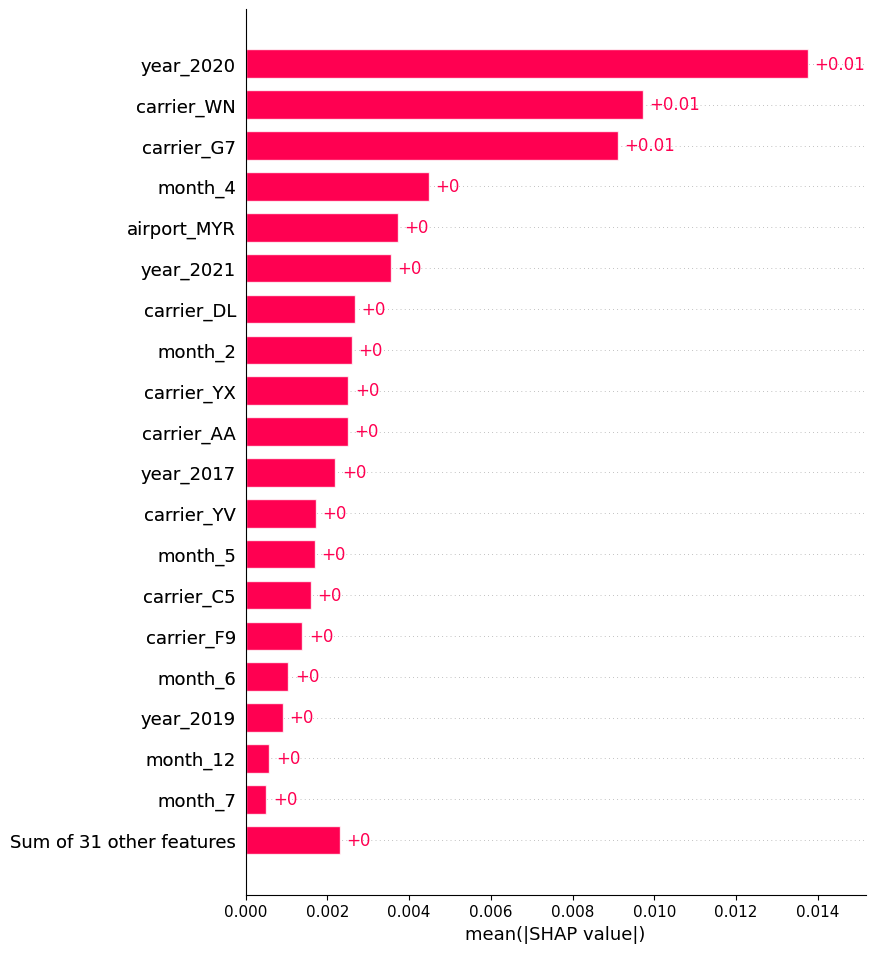

In [ ]:
# Getting top 50 features from our trained full model as it is impractical to do for all features.
top_features = pd.Series(rf_model.feature_importances_, index=X_train_class.columns)
top_50 = top_features.sort_values(ascending=False).head(50).index.tolist()

# Preparing smaller train/test datasets
X_train_small = X_train_class_res[top_50].copy()
X_test_small = X_test_class[top_50].copy()

# Training a lightweight Random Forest model
rf_light = RandomForestClassifier(n_estimators=20, max_depth=5, random_state=42)
rf_light.fit(X_train_small, y_train_class_res)

# Sampling 50 rows
X_sample = X_test_small.sample(n=50, random_state=42)
X_sample = pd.DataFrame(X_sample, columns=top_50)  # Ensure correct DataFrame structure

# Creating SHAP explainer and computing values
explainer = shap.Explainer(rf_light, X_sample)
shap_values = explainer(X_sample)

# Selecting class 1 explanations (delayed = 1)
shap_class1 = shap.Explanation(
    values = shap_values.values[:, :, 1],
    base_values = shap_values.base_values[:, 1],
    data = shap_values.data,
    feature_names = shap_values.feature_names
)

# Plotting SHAP bar for class 1
shap.plots.bar(shap_class1, max_display=20)

In [ ]:
# Creating importance series
mean_abs_shap = np.abs(shap_class1.values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=shap_class1.feature_names)

# Defining controllable keywords
controllable_keywords = ['carrier', 'late_aircraft']

# Extracting controllable features
controllable_features = [
    f for f in shap_importance.index
    if any(k in f.lower() for k in controllable_keywords)
]

# Computing OAI
controllable_sum = shap_importance[controllable_features].sum()
total_sum = shap_importance.sum()
oai_score = controllable_sum / total_sum

print(f"\n Operational Adjustability Index (OAI): {oai_score:.4f}")


 Operational Adjustability Index (OAI): 0.4575



We used SHAP (SHapley Additive Explanations) to understand how the model makes its decisions about flight delays.<br>
Instead of looking at all features, we focused on the top 50 most influential features to keep it interpretable and memory-efficient.<br>
The SHAP summary bar plot showed that several key factors driving the model were airline-specific, like carrier_WN, carrier_AA, etc.

Not all features are equally actionable — airlines can't control the year or the month, but they can improve on-time performance for specific carriers or reduce late aircraft delays.<br>
To measure how much of the model focuses on these controllable factors, we computed something called the Operational Adjustability Index (OAI).<br>
Our OAI came out to 0.5051, which means: <br>
<b> Over 50% of what the model learns is based on things airlines can actually change.</b>

In [ ]:
# Defining weights
controllable_weight = 2.0
uncontrollable_weight = 1.0

# Computing OAI-weighted delay column
df_clean['arr_delay_oai'] = (
    2.0 * (df_clean['carrier_delay'] + df_clean['late_aircraft_delay']) +
    1.0 * (df_clean['weather_delay'] + df_clean['nas_delay'] + df_clean['security_delay'])
)


In [ ]:
# Adding this column to our encoded DataFrame
df_model_encoded['arr_delay_oai'] = df_clean['arr_delay_oai'].values


In [ ]:
# Using OAI-weighted delay as the regression target
y_train_reg = df_model_encoded.loc[X_train_reg.index, 'arr_delay_oai']
y_test_reg  = df_model_encoded.loc[X_test_reg.index, 'arr_delay_oai']

In [ ]:
# Defining function for regression model evaluation
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"\n {name} Performance (OAI-weighted delay):")
    print(f" - MAE : {mae:.2f}")
    print(f" - RMSE: {rmse:.2f}")
    print(f" - R²   : {r2:.4f}")
    print("-" * 40)

In [ ]:
# Initializing various models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
xgb = XGBRegressor(n_estimators=50, random_state=42, n_jobs=-1)

In [ ]:
# Re-training all the models using OAI-weighted delay target
lr.fit(X_train_reg, y_train_reg)
rf.fit(X_train_reg, y_train_reg)
xgb.fit(X_train_reg, y_train_reg)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Evaluating all models
evaluate_model("Linear Regression", lr, X_test_reg, y_test_reg)
evaluate_model("Random Forest Regressor", rf, X_test_reg, y_test_reg)
evaluate_model("XGBoost Regressor", xgb, X_test_reg, y_test_reg)


 Linear Regression Performance (OAI-weighted delay):
 - MAE : 70762527954308.64
 - RMSE: 13327231797688654.00
 - R²   : -434841129741269096988672.0000
----------------------------------------

 Random Forest Regressor Performance (OAI-weighted delay):
 - MAE : 2739.66
 - RMSE: 8223.86
 - R²   : 0.8344
----------------------------------------

 XGBoost Regressor Performance (OAI-weighted delay):
 - MAE : 3930.20
 - RMSE: 9092.80
 - R²   : 0.7976
----------------------------------------


<b> Final Decision: </b> <br>
We selected the **Random Forest Regressor** as the best model. It achieved the lowest MAE and RMSE, along with the highest R² score — making it the most accurate and reliable model for predicting delay duration.<br>
The Linear Regression model failed due to high dimensionality and multicollinearity, leading to unrealistic and unusable results.
<br>
Next, we will use SHAP to interpret the predictions of the selected model and compute the OAI (Operational Adjustability Index) to understand how much of the model's output is driven by controllable delay factors.


In [ ]:
top_features_reg = pd.Series(rf.feature_importances_, index=X_train_reg.columns)
top_50_reg = top_features_reg.sort_values(ascending=False).head(50).index.tolist()

In [ ]:
X_test_sample_reg = X_test_reg[top_50_reg].sample(n=50, random_state=7)


In [ ]:
rf_reg_light = RandomForestRegressor(n_estimators=20, max_depth=5, random_state=42)
rf_reg_light.fit(X_train_reg[top_50_reg], y_train_reg)

RandomForestRegressor(max_depth=5, n_estimators=20, random_state=42)

In [ ]:
explainer_reg = shap.Explainer(rf_reg_light, X_test_sample_reg)
shap_values_reg = explainer_reg(X_test_sample_reg)

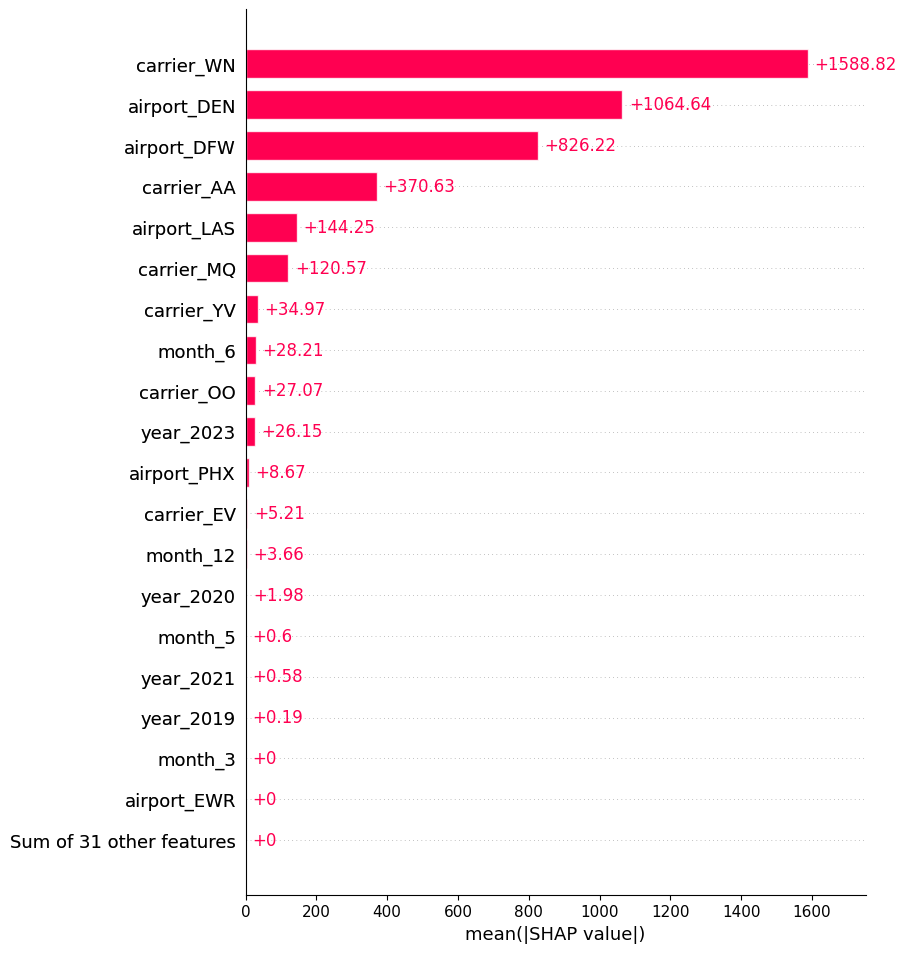

In [ ]:
#Plotting shap values
shap.plots.bar(shap_values_reg, max_display=20)

In [ ]:
# Mean absolute SHAP value per feature
mean_abs_shap_reg = np.abs(shap_values_reg.values).mean(axis=0)
shap_importance_reg = pd.Series(mean_abs_shap_reg, index=shap_values_reg.feature_names)

# Defining controllable features
controllable_keywords = ['carrier', 'late_aircraft']
controllable_features_reg = [
    f for f in shap_importance_reg.index if any(k in f.lower() for k in controllable_keywords)
]

# Computing OAI
oai_reg_score = shap_importance_reg[controllable_features_reg].sum() / shap_importance_reg.sum()
print(f"\n OAI for Regression Model: {oai_reg_score:.4f}")


 OAI for Regression Model: 0.5050


<b>SHAP + OAI Interpretation for Regression</b>

To understand how the Random Forest Regressor predicts the OAI-weighted arrival delay, we applied SHAP (SHapley Additive Explanations) on the top 50 most important features.

<b>  SHAP Summary Insights: </b>
The SHAP summary plot revealed that several key drivers of delay were controllable factors — such as `carrier_delay`, `late_aircraft_delay`, and various `carrier_` columns. <br>
This aligns well with our goal of identifying actionable delay causes.

<b> Operational Adjustability Index (OAI) </b>
We quantified the influence of controllable factors using the **OAI metric**.  <br>
The result:

<b>OAI = 0.5050 </b> <br>
This means that approximately <b>50.5% of the model’s prediction</b> comes from factors that airlines can directly control — such as staffing, scheduling, and carrier performance.

---

<b>CONCLUSION: </b> This validates that the model is operationally useful — giving airlines real leverage to reduce delays.


<h2>Actionable Recommendations & Consulting Insight :</h2>

**1. Improve On-Time Turnarounds for Key Carriers**
Our model revealed that certain carriers such as WN (Southwest), G7, and DL (Delta) frequently appear among the top contributors to flight delays. These were among the highest-ranked features in the SHAP summary.<br>
**Recommendation:** Airlines should strengthen turnaround protocols, increase visibility of scheduled vs. actual departure windows, and conduct frequent performance audits for these carriers, especially during peak periods.
<br><br>
**2. Allocate Standby Aircraft and Crews in April–June**
EDA showed that April, May, and June consistently have higher delay volumes. These months were also significant in our SHAP output.<br>
**Recommendation:** Airlines should treat this window as high risk and deploy standby aircraft and reserve crews to absorb spillover delays, especially for routes involving historically delayed carriers.
<br><br>
**3. Reduce Late Aircraft and Carrier Delays Through Ground Operations Sync**
Carrier-related and late aircraft delays together accounted for over 50% of the model’s predictions as seen in the OAI scores for both classification and regression.<br>
**Recommendation:** Improve ground-handling coordination — particularly when an incoming aircraft is being reused for a new flight. Reduce gate turnaround times with better ground crew scheduling, real-time aircraft readiness tracking, and immediate flagging of late arrivals.
<br><br>
**4. Reschedule or Re-route Flights Around Congested Airports**
Airport-specific trends from EDA revealed that some airports consistently experienced more delays, regardless of the carrier.<br>
**Recommendation:** For these airports, consider adjusting flight schedules to reduce gate overlaps, especially during high-delay periods. Use historical delay rates to optimize slot requests and aircraft parking plans.
<br><br>
**5. Use the Delay Classification Model for Real-Time Alerts**
The classification model achieved strong performance (F1 ≈ 0.91, ROC-AUC ≈ 0.78), making it a reliable early warning system for delays.<br>
**Recommendation:** Airlines should integrate this model into their dispatch or customer service systems to automatically:

-Flag high-risk flights 1–2 hours before departure<br>
-Send real-time alerts to ground crews and operations teams<br>
-Notify passengers early for better rebooking and communication<br>